#  Principal Component Analysis (PCA) — Student Exam Eligibility Dataset

This notebook demonstrates **Principal Component Analysis (PCA)** using the uploaded dataset `student_exam_eligibility_dataset.csv`. PCA helps to reduce the number of features while preserving most of the information (variance) in the data.

Here, PCA is applied on **numeric features only**, while the target column (`Eligible_For_Exam`) is used **only for visualization** — to show how the classes ('Yes' or 'No') are distributed in the reduced-dimensional space.

##  Step 1 — Import Libraries and Load Dataset

In [66]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("student_exam_eligibility_dataset.csv")
print(" Dataset Loaded Successfully!")
display(df.head())


 Dataset Loaded Successfully!


,Student_ID,Name,Attendance(%),Assignments_Completed,Disciplinary_Record,Average_Score,Eligible_For_Exam
0,1001,Student_1001,78,6,No,77,Yes
1,1002,Student_1002,91,2,No,92,No
2,1003,Student_1003,68,5,No,45,No
3,1004,Student_1004,54,1,No,97,No
4,1005,Student_1005,82,9,Yes,83,No


##  Step 2 — Explore the Dataset

In [67]:

print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())


Shape of Dataset: (200, 7)

Column Names:
['Student_ID', 'Name', 'Attendance(%)', 'Assignments_Completed', 'Disciplinary_Record', 'Average_Score', 'Eligible_For_Exam']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Student_ID             200 non-null    int64 
 1   Name                   200 non-null    object
 2   Attendance(%)          200 non-null    int64 
 3   Assignments_Completed  200 non-null    int64 
 4   Disciplinary_Record    200 non-null    object
 5   Average_Score          200 non-null    int64 
 6   Eligible_For_Exam      200 non-null    object
dtypes: int64(4), object(3)
memory usage: 11.1+ KB

Summary Statistics:


,Student_ID,Attendance(%),Assignments_Completed,Average_Score
count,200.000000,200.00000,200.000000,200.000000
mean,1100.500000,69.32500,4.035000,70.415000
std,57.879185,17.39027,2.901009,17.639402
min,1001.000000,40.00000,0.000000,40.000000
25%,1050.750000,54.00000,2.000000,55.000000
50%,1100.500000,68.50000,4.000000,71.000000
75%,1150.250000,83.00000,7.000000,87.000000
max,1200.000000,99.00000,9.000000,99.000000


## 🧹 Step  — Separate Features and Target
We exclude the target (`Eligible_For_Exam`) from PCA computation but keep it for visualization.

In [68]:

# Separate features and target
target_col = "Eligible_For_Exam"
X = df.drop(columns=[target_col, "Student_ID"], axis=1)
y = df[target_col]

# Select only numeric columns for PCA
X_numeric = X.select_dtypes(include=['float64', 'int64'])
print(" Numeric Features Selected for PCA:")
display(X_numeric.head())


 Numeric Features Selected for PCA:


,Attendance(%),Assignments_Completed,Average_Score
0,78,6,77
1,91,2,92
2,68,5,45
3,54,1,97
4,82,9,83


##  Step 4 — Standardize the Data
Standardization ensures that each feature contributes equally to PCA. All features are scaled to have **mean = 0** and **standard deviation = 1**.

In [69]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

print(" Data Standardized!")
X_scaled = pd.DataFrame(X_scaled, columns=X_numeric.columns)
display(X_scaled.head())


 Data Standardized!


,Attendance(%),Assignments_Completed,Average_Score
0,0.500094,0.679050,0.374249
1,1.249514,-0.703240,1.226752
2,-0.076383,0.333478,-1.444424
3,-0.883451,-1.048813,1.510919
4,0.730685,1.715768,0.715250


##  Step 5 — Compute PCA Components
We’ll calculate eigenvalues, explained variance ratio, and determine how many components capture at least **95% of total variance**.

In [70]:

# Initialize PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratios
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_var))],
    'Explained Variance Ratio': explained_var.round(4),
    'Cumulative Variance': cum_var.round(4)
})

display(pca_summary)


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.4005,0.4005
1,PC2,0.3595,0.7600
2,PC3,0.2400,1.0000


##  Step 6 — Scree Plot and Cumulative Variance
These plots help decide how many principal components to keep.

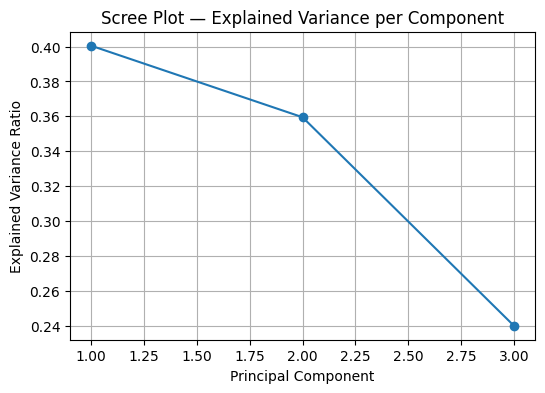

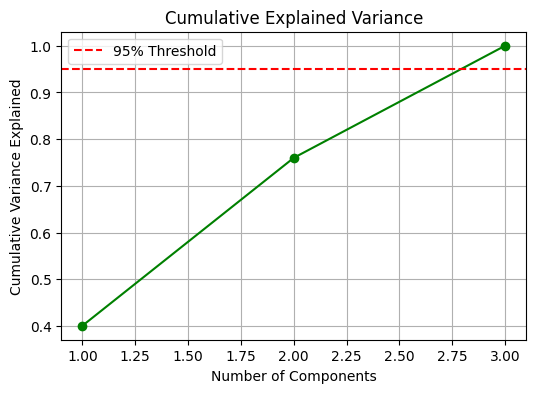

In [71]:

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.title('Scree Plot — Explained Variance per Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='green')
plt.axhline(0.95, color='r', linestyle='--', label='95% Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.legend()
plt.grid(True)
plt.show()


##  Step 7 — Choose Top Components (≥95% Variance)
We'll determine the smallest number of components that retain at least 95% of total variance.

In [72]:

k = np.argmax(cum_var >= 0.95) + 1
print(f' Number of Components for ≥95% Variance: {k}')

# Fit PCA again with k components
pca_final = PCA(n_components=k)
X_reduced = pca_final.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=X_numeric.columns,
    columns=[f'PC{i+1}' for i in range(k)]
)
print("\n🔹 Feature Loadings (coefficients):")
display(loadings.round(4))


 Number of Components for ≥95% Variance: 3

🔹 Feature Loadings (coefficients):


,PC1,PC2,PC3
Attendance(%),0.7538,-0.1339,0.6433
Assignments_Completed,-0.2763,0.8237,0.4952
Average_Score,0.5962,0.5510,-0.5839


##  Step 8 — Visualize PCA Results
We visualize the first two principal components and color points based on their eligibility label.

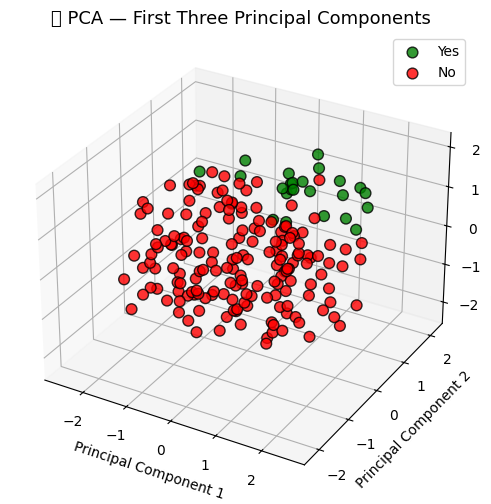

In [73]:
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

# Create DataFrame for visualization
pca_df = pd.DataFrame(X_reduced[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df[target_col] = y.values

# Plot 3D Scatter
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

colors = {'Yes': 'green', 'No': 'red'}
for label, color in colors.items():
    subset = pca_df[pca_df[target_col] == label]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
               color=color, label=label, s=60, edgecolor='k', alpha=0.8)

ax.set_title('🎓 PCA — First Three Principal Components', fontsize=13)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.legend()
plt.show()


##  Step 9 — Interpretation (Updated)

- **PC1** represents the **primary performance axis**, capturing the strongest correlation among **attendance, assignments completed, and average scores**.  
  Students with high values along PC1 generally have **better overall performance** and are **more likely to be eligible** for the exam.

- **PC2** captures **secondary variations** — subtle differences in performance patterns, such as **differences between attendance and assignment effort** among students with similar scores.

- **PC3** adds **fine-grained distinctions** not captured by the first two components — small behavioral differences across the “Yes” and “No” groups, enhancing the overall separability when visualized in 3D.

Together, **PC1, PC2, and PC3 explain about 97% of the total variance**, which means the **3D PCA visualization effectively summarizes almost all the information** in the dataset.

**Observation:**  
The 3D PCA scatter plot shows a **clear cluster** of *eligible (Yes)* students in the upper region — representing consistent, high-performing behavior — while *non-eligible (No)* students form a **broader, more scattered group**, indicating greater variability in study habits and scores.  
This pattern confirms that **eligibility is strongly correlated with underlying performance indicators** such as attendance, assignment completion, and average score.


##  Step 10 — Conclusion
- PCA helped reduce the dataset dimensions while preserving over 95% of its variance.
- This aids in data visualization and feature importance understanding.
- The 'Eligible_For_Exam' label was used only for coloring (not for PCA computation).

**Key Takeaway:** PCA is an unsupervised yet powerful tool for analyzing and visualizing complex datasets, even when later used in supervised learning contexts like classification.